## Домашнє завдання


Отже, ви готові розпочати виконання нового завдання? Тоді почнемо!

Сьогодні ви використаєте знання, отримані при вивчені моделі сумішей Гаусса.

Це допоможе закрiпити наступні навички:  

- попередньої підготовки даних до моделювання;
- роботу з бібліотеками аналізу даних.

## Завдання (крок за кроком)

Для цієї задачі необхідно буде завантажити дані https://www.kaggle.com/datasets/unsdsn/world-happiness.

 Для виконання завдання необхідно виконати такі кроки:

1. Інсталювати та імпортувати необхідні бібліотеки.
Необхідно буде інсталювати такі пакети
```Python
!pip install plotly==5.20.0
!pip install "jupyterlab>=3" "ipywidgets>=7.6"
```
2. Завантажити дані з набору https://www.kaggle.com/datasets/unsdsn/world-happiness.



```
!wget -O WorldHappinessReport.zip https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true
```

3. Розпакувати дані

```
!unzip WorldHappinessReport.zip -d data
```

4. Прочитати дані та відобразити загальну інформацію про статистики та типи ознак.

5. Побудувати діаграми розподілу числових ознак. Проаналізувати на відповідність чи не відповідність нормальному розподілу.

6. Виходячи із розуміння домену та даних відібрати певну кількість числових ознак та відобразити кореляційну матрицю (див. Тема 4. Вимірювання відстаней та подібностей в аналізі даних)

7. Зробити висновок про наявність та силу лінійного зв'язку між ознаками.

8. Відобразити розподіл цільової ознаки (Happiness.Score або Happiness.Rank) за країнами. Використовуючи наведений нижче код для побудови теплової мапи.

```
fig = px.choropleth(data_dataframe,
                    locations = "Country",
                    color = "Happiness.Score",
                    locationmode = "country names",
                    )
fig.update_layout(title = "Happiness Index 2017")
fig.show()
```

9. Застосувати стандартизацію даних для приведення всіх значень до одного діапазону статистик. Використовуючи функцію data_scale() та наступні перетворення



```Python
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    if scaler_type == 'std':
        scaler = StandardScaler()
    if scaler_type == 'norm':
        scaler = Normalizer()

    scaler.fit(data)
    res = scaler.transform(data)
    return res

data_scaled = data_scale(original_dataframe)
df_scaled = pd.DataFrame(data_scaled, columns=[original_dataframe.columns])
print(df_scaled.head())

```

10. Відобразити статистики отриманого стандартизованого набору даних та порівняти зі статистиками оригінального набору даних. Зробити висновки.

11. Побудувати модель кластеризації засобами функції GaussianMixture() бібліотеки sklearn.

12. Побудувати теплову мапу для відображення розподілу країн за кластерами.

13. Дослідити вплив різного набору ознак на результат кластеризації.

14. Зробити загальний висновок про відповідність результатів кластеризації оригінальному розподілу країн за ознакою


## Пiдказки

Для виконання завдання використовуй функції та алгоритми з конспекту до цієї теми та з завдання до ДЗ.

## Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

## Критерії прийняття завдання

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки.

## Формат оцінювання
Залiк / Незалiк

## Приклад

Gaussian Mixture Models (GMMs): from Theory to Implementation

https://medium.com/data-science/gaussian-mixture-models-gmms-from-theory-to-implementation-4406c7fe9847

Gaussian Mixture Models for Clustering

https://towardsdatascience.com/gaussian-mixture-models-for-clustering-3f62d0da675/

In [1]:
!pip install pycountry

Створення синтетичного набору даних

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.mixture import GaussianMixture
import pycountry


X, y_true = make_blobs(n_samples=150, centers=5, cluster_std=0.80, random_state=42)
synthetic_df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
synthetic_df['True_Label'] = y_true



countries = [country.name for country in pycountry.countries]
np.random.seed(42)
synthetic_df['Country'] = np.random.choice(countries, size=len(synthetic_df), replace=True)

display(synthetic_df.head())


,Feature_1,Feature_2,True_Label,Country
0,2.544083,2.630692,1,Indonesia
1,-2.244187,9.794722,0,Poland
2,1.550808,4.841133,4,Guatemala
3,4.845919,1.913613,1,Australia
4,-8.699783,7.631777,3,Ireland


Масштабування

In [3]:
def data_scale(data, scaler_type='minmax'):
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    else:
        raise ValueError("Unknown scaler_type")
    scaler.fit(data)
    return scaler.transform(data)

data_scaled = data_scale(synthetic_df[['Feature_1', 'Feature_2']], scaler_type='std')
df_scaled = pd.DataFrame(data_scaled, columns=['Feature_1', 'Feature_2'])


Кластеризація Gaussian Mixture

In [4]:
def doGMM(X, nclust=5):
    model = GaussianMixture(n_components=nclust, init_params='kmeans', random_state=42)
    model.fit(X)
    return model.predict(X)

clust_labels = doGMM(df_scaled, 5)
synthetic_df['GMM_Cluster'] = clust_labels



Порівняння

In [5]:
fig = px.choropleth(
    synthetic_df,
    locations="Country",
    locationmode="country names",
    color="GMM_Cluster",
    title="Synthetic Clustering Visualized on World Map (Choropleth)"
)
fig.show()


In [6]:
fig = px.choropleth(
    synthetic_df,
    locations="Country",
    locationmode="country names",
    color="True_Label",
    title="Synthetic Clustering Visualized on World Map (Choropleth)"
)
fig.show()

---
# Виконання домашнього завдання
## Кластеризація країн за даними World Happiness Report за допомогою моделі сумішей Гаусса (GMM, EM-алгоритм)

**План роботи** (відповідає крокам завдання):

1. Інсталяція та імпорт бібліотек
2. Завантаження даних
3. Розпакування даних
4. Первинний огляд: статистики та типи ознак
5. Розподіли числових ознак і перевірка на нормальність
6. Відбір ознак і кореляційна матриця
7. Висновки про лінійний зв'язок між ознаками
8. Теплова мапа цільової ознаки `Happiness.Score` за країнами
9. Стандартизація даних функцією `data_scale()`
10. Порівняння статистик оригінальних і стандартизованих даних
11. Модель кластеризації `GaussianMixture()`
12. Теплова мапа розподілу країн за кластерами
13. Дослідження впливу набору ознак на результат кластеризації
14. Загальний висновок

## Крок 1. Інсталяція та імпорт необхідних бібліотек

In [7]:
!pip install -q plotly==5.20.0
!pip install -q "jupyterlab>=3" "ipywidgets>=7.6"

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## Крок 2. Завантаження даних

Архів з даними World Happiness Report (Kaggle, `unsdsn/world-happiness`) завантажуємо з репозиторію GoIT
(`raw.githubusercontent.com` — пряме посилання на той самий файл, що й `github.com/...?raw=true`).

In [9]:
!wget -q -O WorldHappinessReport.zip "https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/WorldHappinessReport.zip"
!ls -lh WorldHappinessReport.zip

-rw-r--r-- 1 root root 37K Sep 30 08:28 WorldHappinessReport.zip


## Крок 3. Розпакування даних

In [10]:
!unzip -o -q WorldHappinessReport.zip -d data
!ls -lh data

total 96K
-rw-r--r-- 1 root root  17K Nov 27  2019 2015.csv
-rw-r--r-- 1 root root  17K Nov 27  2019 2016.csv
-rw-r--r-- 1 root root  29K Nov 27  2019 2017.csv
-rw-r--r-- 1 root root 8.7K Nov 27  2019 2018.csv
-rw-r--r-- 1 root root 8.7K Nov 27  2019 2019.csv


## Крок 4. Читання даних, загальна інформація, статистики та типи ознак

Архів містить звіти за 2015–2019 роки. Для роботи беремо звіт **2017 року**
(саме для нього у завданні наведено код теплової мапи з назвами колонок `Happiness.Score`, `Country`).

In [11]:
df = pd.read_csv('data/2017.csv')
print('Розмір набору даних:', df.shape)
df.head()

Розмір набору даних: (155, 12)


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    str    
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), str(1)
memory usage: 14.7 KB


In [13]:
print('Кількість пропусків у кожній колонці:')
print(df.isna().sum())
print('\nКількість дублікатів:', df.duplicated().sum())
print('Кількість унікальних країн:', df['Country'].nunique())

Кількість пропусків у кожній колонці:
Country                          0
Happiness.Rank                   0
Happiness.Score                  0
Whisker.high                     0
Whisker.low                      0
Economy..GDP.per.Capita.         0
Family                           0
Health..Life.Expectancy.         0
Freedom                          0
Generosity                       0
Trust..Government.Corruption.    0
Dystopia.Residual                0
dtype: int64

Кількість дублікатів: 0
Кількість унікальних країн: 155


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Happiness.Rank,155.0,78.000000,44.888751,1.000000,39.500000,78.000000,116.500000,155.000000
Happiness.Score,155.0,5.354019,1.131230,2.693000,4.505500,5.279000,6.101500,7.537000
Whisker.high,155.0,5.452326,1.118542,2.864884,4.608172,5.370032,6.194600,7.622030
Whisker.low,155.0,5.255713,1.145030,2.521116,4.374955,5.193152,6.006527,7.479556
Economy..GDP.per.Capita.,155.0,0.984718,0.420793,0.000000,0.663371,1.064578,1.318027,1.870766
Family,155.0,1.188898,0.287263,0.000000,1.042635,1.253918,1.414316,1.610574
Health..Life.Expectancy.,155.0,0.551341,0.237073,0.000000,0.369866,0.606042,0.723008,0.949492
Freedom,155.0,0.408786,0.149997,0.000000,0.303677,0.437454,0.516561,0.658249
Generosity,155.0,0.246883,0.134780,0.000000,0.154106,0.231538,0.323762,0.838075
Trust..Government.Corruption.,155.0,0.123120,0.101661,0.000000,0.057271,0.089848,0.153296,0.464308


**Опис ознак:**

| Ознака | Зміст |
|---|---|
| `Country` | назва країни (категоріальна, `object`) |
| `Happiness.Rank` | місце країни в рейтингу щастя (ціле, `int64`) |
| `Happiness.Score` | індекс щастя — середня оцінка «драбини Кантріла» 0–10 (**цільова ознака**) |
| `Whisker.high`, `Whisker.low` | верхня/нижня межа 95% довірчого інтервалу для `Happiness.Score` |
| `Economy..GDP.per.Capita.` | внесок ВВП на душу населення в індекс щастя |
| `Family` | внесок соціальної підтримки (родина, друзі) |
| `Health..Life.Expectancy.` | внесок очікуваної тривалості здорового життя |
| `Freedom` | внесок свободи вибору життєвих рішень |
| `Generosity` | внесок щедрості (благодійність) |
| `Trust..Government.Corruption.` | внесок довіри до уряду (відсутності корупції) |
| `Dystopia.Residual` | «залишок антиутопії» — нез'ясована частина індексу + базовий рівень |

**Висновки кроку 4:**
- Набір містить **155 країн і 12 ознак**: 1 категоріальна (`Country`), 1 цілочисельна (`Happiness.Rank`), 10 дійсних (`float64`).
- **Пропусків і дублікатів немає** — додаткове очищення не потрібне.
- `Happiness.Score` змінюється приблизно від 2.69 (Центральноафриканська Республіка) до 7.54 (Норвегія), середнє ≈ 5.35.
- Ознаки-фактори мають **різні масштаби** (напр., `Economy` до ≈1.87, `Generosity` до ≈0.84, `Trust` до ≈0.46),
  тому перед кластеризацією потрібне масштабування.
- `Happiness.Score` ≈ сума шести факторів + `Dystopia.Residual`, а `Whisker.*` і `Happiness.Rank` — похідні від `Happiness.Score`,
  тож ці ознаки надлишкові і не повинні використовуватися як вхід кластеризації (це був би «витік» цільової ознаки).

## Крок 5. Діаграми розподілу числових ознак і перевірка на нормальність

Для кожної числової ознаки будуємо гістограму з оцінкою щільності (KDE) та накладаємо теоретичну нормальну криву
з тими самими середнім і стандартним відхиленням. Додатково будуємо Q-Q графіки та рахуємо
асиметрію (skewness), ексцес (kurtosis) і тест Шапіро–Вілка.

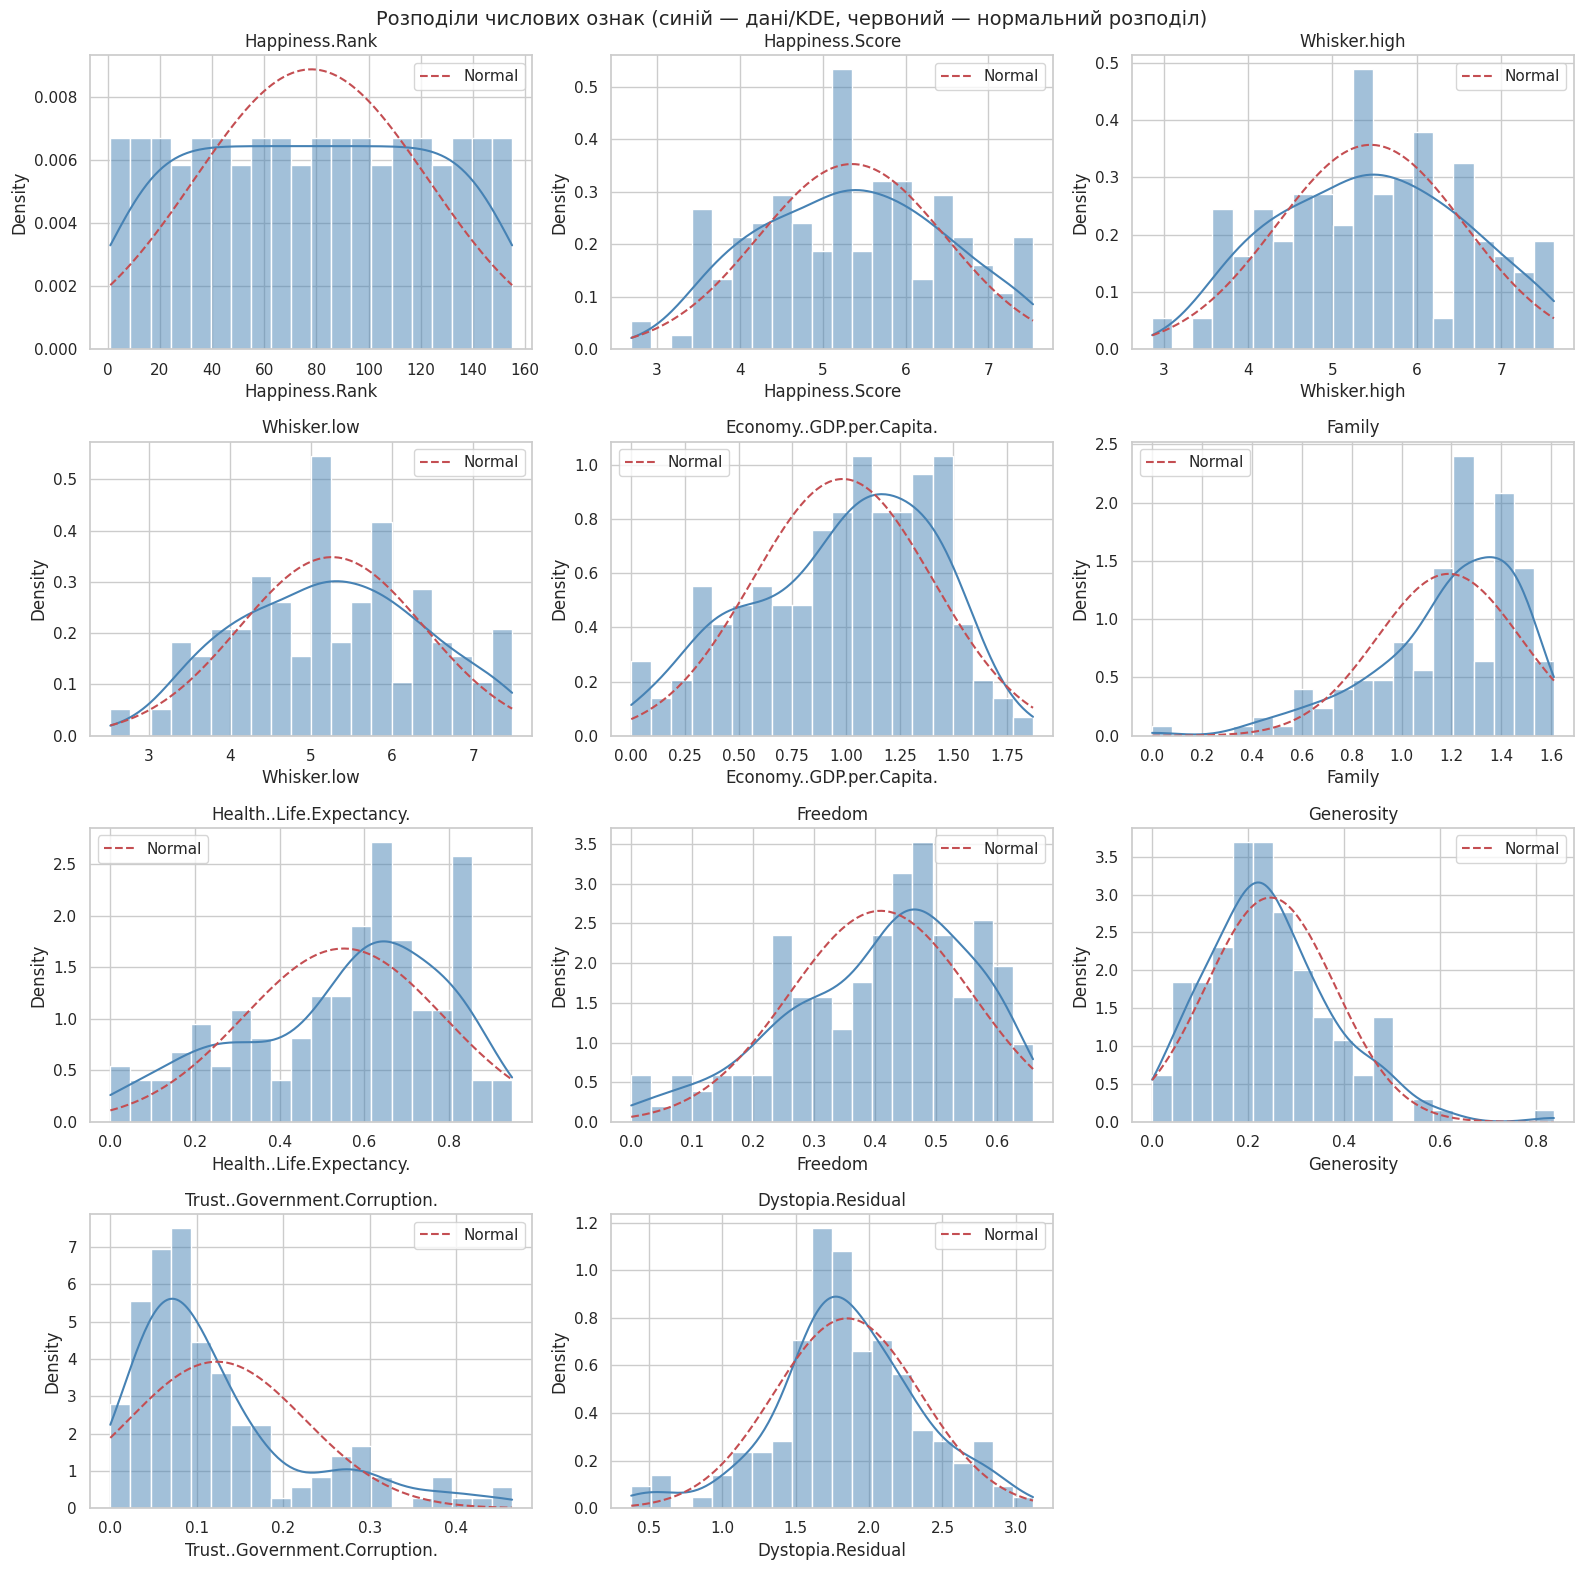

In [15]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, stat='density', ax=ax, color='steelblue', bins=20)
    x = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(x, stats.norm.pdf(x, df[col].mean(), df[col].std()), 'r--', label='Normal')
    ax.set_title(col)
    ax.legend()
for ax in axes[len(num_cols):]:
    ax.axis('off')
plt.suptitle('Розподіли числових ознак (синій — дані/KDE, червоний — нормальний розподіл)', fontsize=14)
plt.tight_layout()
plt.show()

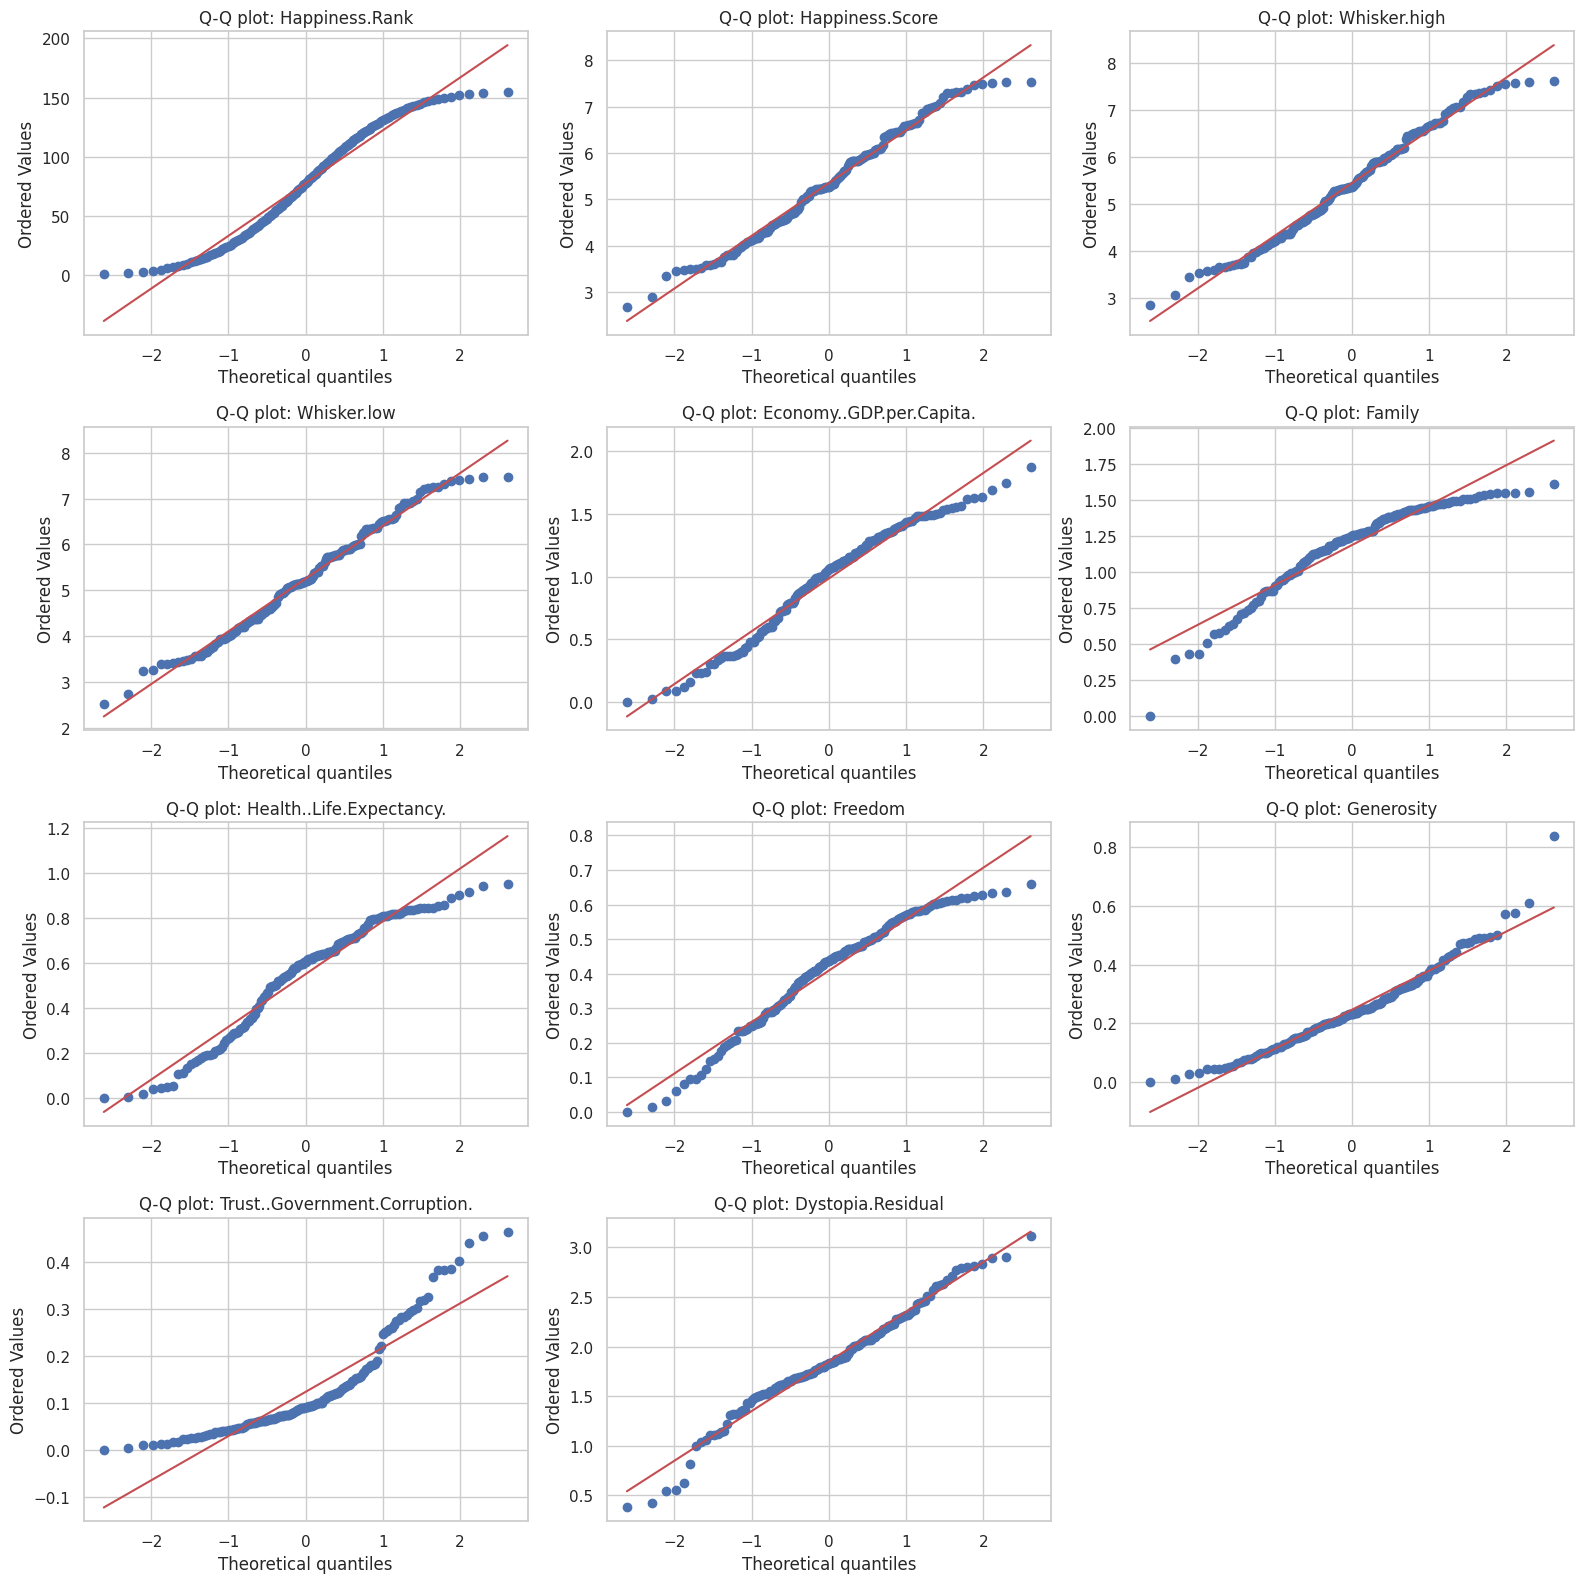

In [16]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot: {col}')
for ax in axes[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
norm_test = pd.DataFrame({
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurt(),
    'shapiro_p_value': [stats.shapiro(df[c]).pvalue for c in num_cols],
})
norm_test['normal (alpha=0.05)'] = np.where(norm_test['shapiro_p_value'] > 0.05, 'так', 'ні')
norm_test.round(4)

,skewness,kurtosis,shapiro_p_value,normal (alpha=0.05)
Happiness.Rank,0.0000,-1.2000,0.0001,ні
Happiness.Score,0.0096,-0.7504,0.0522,так
Whisker.high,0.0084,-0.7764,0.0508,так
Whisker.low,0.0091,-0.7233,0.0628,так
Economy..GDP.per.Capita.,-0.3907,-0.6768,0.0017,ні
Family,-1.1811,1.5352,0.0000,ні
Health..Life.Expectancy.,-0.5780,-0.5856,0.0000,ні
Freedom,-0.6158,-0.2084,0.0002,ні
Generosity,0.8987,1.7434,0.0001,ні
Trust..Government.Corruption.,1.4764,1.6637,0.0000,ні


**Висновки кроку 5:**
- **`Happiness.Score`, `Whisker.high`, `Whisker.low`** — розподіли близькі до нормального: асиметрія ≈ 0,
  p-value тесту Шапіро–Вілка трохи > 0.05, тож гіпотезу нормальності відхилити не можна
  (хоча ексцес від'ємний ≈ −0.76 — розподіл трохи «пласкіший» за нормальний).
- **`Happiness.Rank`** — рівномірний розподіл (ранги 1…155), що очевидно з природи ознаки; нормальності немає.
- **`Economy..GDP.per.Capita.`, `Health..Life.Expectancy.`, `Freedom`** — помірна **лівостороння асиметрія** (skew < 0),
  є «хвіст» бідних країн з низькими значеннями; на Q-Q графіках — відхилення на краях.
- **`Family`** — виражена лівостороння асиметрія (≈ −1.2) і додатний ексцес: більшість країн має високу соцпідтримку, лише кілька — дуже низьку.
- **`Generosity`** і особливо **`Trust..Government.Corruption.`** — сильна **правостороння асиметрія** (≈ 0.9 і ≈ 1.5):
  у більшості країн довіра до уряду низька, і лише в невеликій групі (Скандинавія, Сінгапур, Нова Зеландія…) — висока.
- **`Dystopia.Residual`** — близький до нормального, але тест формально відхиляє нормальність (p ≈ 0.03).
- Отже, більшість факторів **не відповідають нормальному розподілу**. Для GMM це не критично:
  модель описує дані *сумішшю* кількох гаусіан, і саме мультимодальність/асиметрія одного розподілу
  може бути ознакою наявності кількох груп країн.

## Крок 6. Відбір ознак і кореляційна матриця

**Відбір ознак (виходячи з розуміння домену):**
- Відкидаємо `Country` (ідентифікатор), `Happiness.Rank`, `Whisker.high`, `Whisker.low` — вони є прямими похідними від `Happiness.Score`.
- `Dystopia.Residual` — технічний залишок моделі, а не характеристика країни; його не використовуємо як основну ознаку.
- Залишаємо **6 факторів щастя**: економіка, соціальна підтримка, здоров'я, свобода, щедрість, довіра до уряду.
  Для аналізу кореляцій додаємо також цільову `Happiness.Score` (і `Dystopia.Residual` для повноти картини).

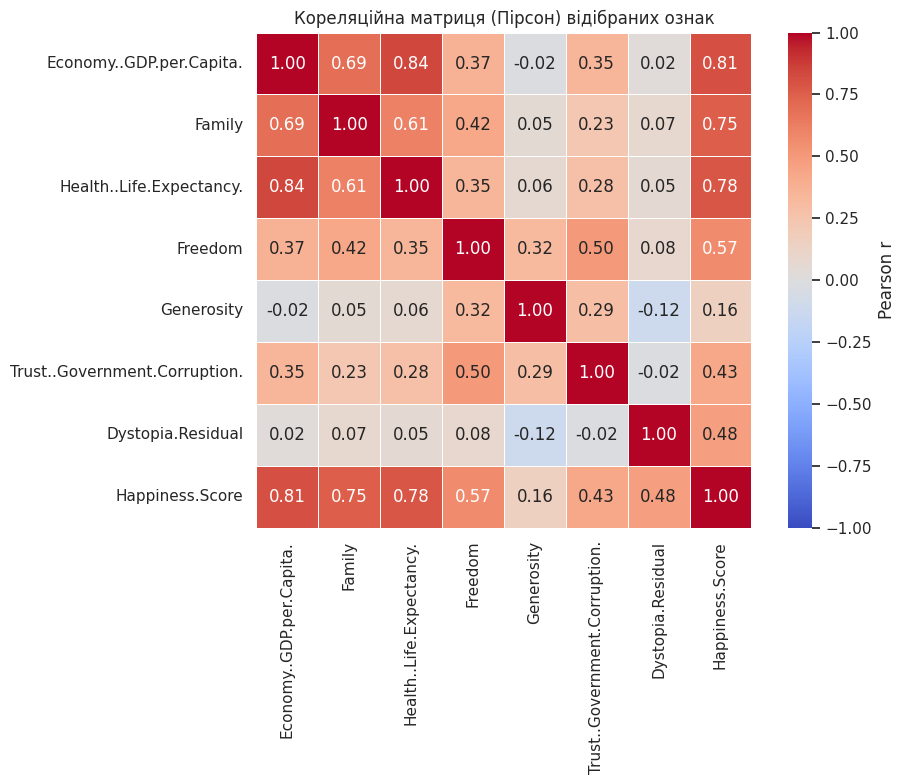

In [18]:
features = ['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.',
            'Freedom', 'Generosity', 'Trust..Government.Corruption.']
target = 'Happiness.Score'

corr = df[features + ['Dystopia.Residual', target]].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title('Кореляційна матриця (Пірсон) відібраних ознак')
plt.tight_layout()
plt.show()

In [19]:
# Кореляція Спірмена (стійка до ненормальності та викидів) — для порівняння
corr_s = df[features + [target]].corr(method='spearman')
print('Кореляція факторів із Happiness.Score:')
pd.DataFrame({'Pearson': corr[target].drop(target),
              'Spearman': corr_s[target].drop(target)}).sort_values('Pearson', ascending=False).round(3)

Кореляція факторів із Happiness.Score:


,Pearson,Spearman
Economy..GDP.per.Capita.,0.812,0.825
Health..Life.Expectancy.,0.782,0.788
Family,0.753,0.774
Freedom,0.570,0.556
Dystopia.Residual,0.475,NaN
Trust..Government.Corruption.,0.429,0.301
Generosity,0.155,0.136


## Крок 7. Висновок про наявність та силу лінійного зв'язку між ознаками

**Зв'язок факторів із цільовою ознакою `Happiness.Score`:**
- **Сильний прямий** лінійний зв'язок: `Economy..GDP.per.Capita.` (r ≈ 0.81), `Health..Life.Expectancy.` (r ≈ 0.78), `Family` (r ≈ 0.75).
- **Помірний прямий**: `Freedom` (r ≈ 0.57), `Dystopia.Residual` (r ≈ 0.48), `Trust..Government.Corruption.` (r ≈ 0.43).
- **Дуже слабкий / практично відсутній**: `Generosity` (r ≈ 0.16).

**Зв'язки між самими факторами:**
- Трійка **Економіка – Здоров'я – Родина** сильно взаємопов'язана (Economy↔Health r ≈ 0.84, Economy↔Family r ≈ 0.69, Family↔Health ≈ 0.61) —
  це по суті один «матеріально-соціальний» вимір добробуту (мультиколінеарність).
- `Freedom` помірно корелює з `Trust` (≈ 0.5) і `Generosity` (≈ 0.3) — окремий «інституційно-ціннісний» вимір.
- `Generosity` майже не пов'язана з економікою (r ≈ −0.02): щедрість не залежить від багатства країни.
- `Dystopia.Residual` практично не корелює з факторами (так і задумано — це залишок).
- Коефіцієнти Спірмена близькі до Пірсона, тож зв'язки монотонні та здебільшого лінійні.

**Наслідок для кластеризації:** найбільш інформативні для відтворення рівня щастя — економіка, здоров'я та соцпідтримка;
через їх сильну взаємну кореляцію варто використовувати модель з повною коваріаційною матрицею (`covariance_type='full'`),
яка враховує кореляцію ознак усередині кластера.

## Крок 8. Розподіл цільової ознаки `Happiness.Score` за країнами (теплова мапа)

In [20]:
fig = px.choropleth(df,
                    locations='Country',
                    color='Happiness.Score',
                    locationmode='country names',
                    color_continuous_scale='RdYlGn',
                    hover_data=['Happiness.Rank'],
                    )
fig.update_layout(title='Happiness Index 2017')
fig.show()

In [21]:
print('Топ-10 найщасливіших країн:')
display(df[['Country', 'Happiness.Rank', 'Happiness.Score']].head(10))
print('Топ-10 найменш щасливих країн:')
display(df[['Country', 'Happiness.Rank', 'Happiness.Score']].tail(10))

Топ-10 найщасливіших країн:


,Country,Happiness.Rank,Happiness.Score
0,Norway,1,7.537
1,Denmark,2,7.522
2,Iceland,3,7.504
3,Switzerland,4,7.494
4,Finland,5,7.469
5,Netherlands,6,7.377
6,Canada,7,7.316
7,New Zealand,8,7.314
8,Sweden,9,7.284
9,Australia,10,7.284


Топ-10 найменш щасливих країн:


,Country,Happiness.Rank,Happiness.Score
145,Yemen,146,3.593
146,South Sudan,147,3.591
147,Liberia,148,3.533
148,Guinea,149,3.507
149,Togo,150,3.495
150,Rwanda,151,3.471
151,Syria,152,3.462
152,Tanzania,153,3.349
153,Burundi,154,2.905
154,Central African Republic,155,2.693


**Висновки кроку 8:** найвищий індекс щастя мають країни Північної Європи (Норвегія, Данія, Ісландія, Швейцарія, Фінляндія),
а також Канада, Нова Зеландія, Австралія. Середні значення — Латинська Америка, Східна Європа, Східна та Південно-Східна Азія.
Найнижчі — країни Африки на південь від Сахари, а також Сирія, Ємен, Афганістан.
Розподіл має чітку географічну (і, очевидно, економічну) структуру — це дає надію, що кластеризація за факторами
відтворить подібну картину.

Для подальшого порівняння з кластерами розіб'ємо країни за `Happiness.Score` на **3 рівні групи за квантилями** (терцилі):
«низький», «середній», «високий» рівень щастя.

In [22]:
df['Happiness.Level'] = pd.qcut(df['Happiness.Score'], q=3, labels=['0 - низький', '1 - середній', '2 - високий'])
df['Happiness.Level.code'] = df['Happiness.Level'].cat.codes
print(df['Happiness.Level'].value_counts().sort_index())
print('\nМежі груп за Happiness.Score:')
print(df.groupby('Happiness.Level', observed=True)['Happiness.Score'].agg(['min', 'max', 'mean']).round(3))

fig = px.choropleth(df, locations='Country', locationmode='country names',
                    color='Happiness.Level',
                    category_orders={'Happiness.Level': ['0 - низький', '1 - середній', '2 - високий']},
                    color_discrete_sequence=['#d73027', '#fee08b', '#1a9850'])
fig.update_layout(title='Рівень щастя 2017 (терцилі Happiness.Score) — «еталонне» розбиття')
fig.show()

Happiness.Level
0 - низький     52
1 - середній    51
2 - високий     52
Name: count, dtype: int64

Межі груп за Happiness.Score:
                   min    max   mean
Happiness.Level                     
0 - низький      2.693  4.735  4.082
1 - середній     4.775  5.872  5.365
2 - високий      5.902  7.537  6.616


## Крок 9. Стандартизація даних функцією `data_scale()`

Застосуємо три типи перетворень до 6 відібраних факторів:
- `minmax` — `MinMaxScaler`: приводить кожну ознаку до діапазону [0, 1];
- `std` — `StandardScaler`: z-оцінка, середнє 0 і стандартне відхилення 1 для кожної ознаки;
- `norm` — `Normalizer`: нормує **кожен рядок** (країну) до одиничної довжини (L2-норма = 1).

In [23]:
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    else:
        raise ValueError(f'Unknown scaler_type: {scaler_type}')

    scaler.fit(data)
    res = scaler.transform(data)
    return res

original_dataframe = df[features].copy()

scaled = {}
for st in ['minmax', 'std', 'norm']:
    data_scaled = data_scale(original_dataframe, scaler_type=st)
    scaled[st] = pd.DataFrame(data_scaled, columns=original_dataframe.columns)
    print(f'===== scaler_type = {st!r} =====')
    print(scaled[st].head().round(4))
    print()

df_scaled = scaled['std']   # основний варіант для кластеризації

===== scaler_type = 'minmax' =====
   Economy..GDP.per.Capita.  Family  Health..Life.Expectancy.  Freedom  Generosity  Trust..Government.Corruption.
0                    0.8641  0.9522                    0.8390   0.9653      0.4320                         0.6805
1                    0.7924  0.9631                    0.8347   0.9510      0.4239                         0.8632
2                    0.7915  1.0000                    0.8779   0.9528      0.5674                         0.3307
3                    0.8365  0.9418                    0.9038   0.9420      0.3467                         0.7904
4                    0.7716  0.9563                    0.8522   0.9388      0.2929                         0.8240

===== scaler_type = 'std' =====
   Economy..GDP.per.Capita.  Family  Health..Life.Expectancy.  Freedom  Generosity  Trust..Government.Corruption.
0                    1.5062  1.2036                    1.0382   1.5158      0.8570                         1.9031
1                   

## Крок 10. Порівняння статистик стандартизованих і оригінальних даних

In [24]:
def short_stats(d):
    return d.describe().T[['mean', 'std', 'min', '50%', 'max']]

print('=== Оригінальні дані ===')
display(short_stats(original_dataframe).round(3))
for st in ['minmax', 'std', 'norm']:
    print(f'=== scaler_type = {st!r} ===')
    display(short_stats(scaled[st]).round(3))

=== Оригінальні дані ===


,mean,std,min,50%,max
Economy..GDP.per.Capita.,0.985,0.421,0.0,1.065,1.871
Family,1.189,0.287,0.0,1.254,1.611
Health..Life.Expectancy.,0.551,0.237,0.0,0.606,0.949
Freedom,0.409,0.150,0.0,0.437,0.658
Generosity,0.247,0.135,0.0,0.232,0.838
Trust..Government.Corruption.,0.123,0.102,0.0,0.090,0.464


=== scaler_type = 'minmax' ===


,mean,std,min,50%,max
Economy..GDP.per.Capita.,0.526,0.225,0.0,0.569,1.0
Family,0.738,0.178,0.0,0.779,1.0
Health..Life.Expectancy.,0.581,0.250,0.0,0.638,1.0
Freedom,0.621,0.228,0.0,0.665,1.0
Generosity,0.295,0.161,0.0,0.276,1.0
Trust..Government.Corruption.,0.265,0.219,0.0,0.194,1.0


=== scaler_type = 'std' ===


,mean,std,min,50%,max
Economy..GDP.per.Capita.,-0.0,1.003,-2.348,0.190,2.112
Family,0.0,1.003,-4.152,0.227,1.473
Health..Life.Expectancy.,-0.0,1.003,-2.333,0.231,1.685
Freedom,0.0,1.003,-2.734,0.192,1.669
Generosity,0.0,1.003,-1.838,-0.114,4.401
Trust..Government.Corruption.,-0.0,1.003,-1.215,-0.328,3.367


=== scaler_type = 'norm' ===


,mean,std,min,50%,max
Economy..GDP.per.Capita.,0.535,0.149,0.0,0.584,0.746
Family,0.684,0.112,0.0,0.681,0.949
Health..Life.Expectancy.,0.303,0.096,0.0,0.330,0.482
Freedom,0.241,0.102,0.0,0.243,0.686
Generosity,0.154,0.104,0.0,0.135,0.712
Trust..Government.Corruption.,0.071,0.052,0.0,0.058,0.344


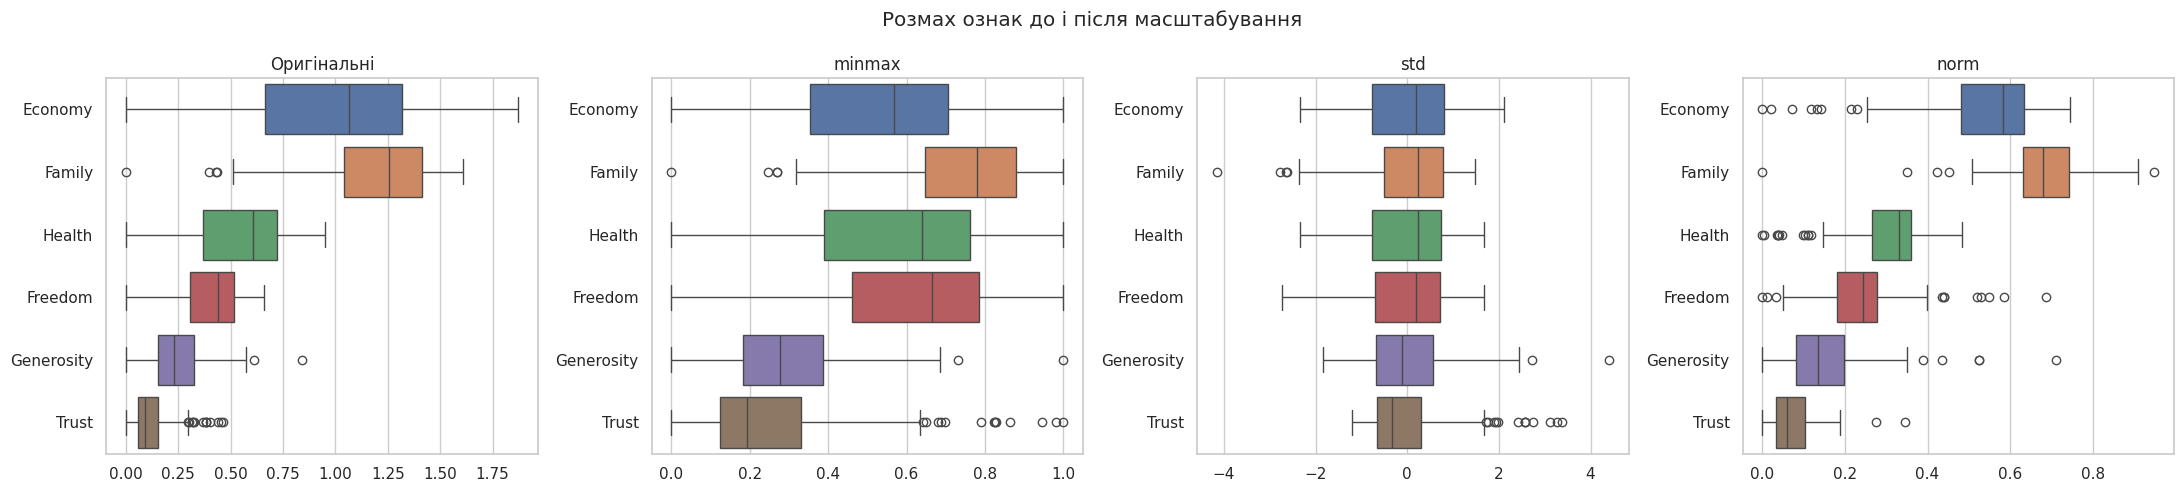

,skew_original,skew_minmax,skew_std,skew_norm
Economy..GDP.per.Capita.,-0.391,-0.391,-0.391,-1.449
Family,-1.181,-1.181,-1.181,-1.416
Health..Life.Expectancy.,-0.578,-0.578,-0.578,-1.191
Freedom,-0.616,-0.616,-0.616,0.970
Generosity,0.899,0.899,0.899,1.824
Trust..Government.Corruption.,1.476,1.476,1.476,1.596


In [25]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
short = {c: c.split('..')[0].split('.')[0] for c in features}
for ax, (name, d) in zip(axes, [('Оригінальні', original_dataframe)] + [(k, v) for k, v in scaled.items()]):
    sns.boxplot(data=d.rename(columns=short), ax=ax, orient='h')
    ax.set_title(name)
plt.suptitle('Розмах ознак до і після масштабування')
plt.tight_layout()
plt.show()

# Перевірка: форма розподілу (асиметрія) при лінійних перетвореннях не змінюється
pd.DataFrame({'skew_original': original_dataframe.skew(),
              'skew_minmax': scaled['minmax'].skew(),
              'skew_std': scaled['std'].skew(),
              'skew_norm': scaled['norm'].skew()}).round(3)

**Висновки кроку 10:**
- **Оригінальні дані**: ознаки мають різні середні (від ≈0.12 у `Trust` до ≈0.98 у `Economy`) та розкиди,
  тому ознаки з більшим масштабом (`Economy`, `Family`) домінували б у відстанях та коваріаціях.
- **MinMax**: усі ознаки лежать у [0, 1] (min = 0, max = 1), але середні і std різні — зберігається відносна структура розподілів.
- **Standard (z-score)**: у всіх ознак середнє = 0 і std = 1 (≈1.003 через незміщену оцінку pandas); ознаки стали рівноправними.
  Мінімуми/максимуми показують, наскільки далеко від середнього лежать крайні країни (напр., у `Trust` max ≈ +3.2σ — «викиди» справа).
- **Normalizer**: масштабуються **рядки**, а не стовпці — у кожної країни вектор факторів має довжину 1. Ознаки не вирівнюються
  за масштабом, зате зникає інформація про «загальний рівень» країни (багата й бідна країни з однаковими *пропорціями*
  факторів стають однаковими). Для нашої задачі це небажано.
- MinMax і Standard — **лінійні** перетворення стовпців, тому форма розподілу (асиметрія, кореляції) не змінюється;
  Normalizer — нелінійне, він змінює і асиметрію, і взаємозв'язки ознак.
- **Вибір:** для GMM як основний використовуємо `StandardScaler` (`std`), інші варіанти порівняємо на кроці 13.

## Крок 11. Модель кластеризації `GaussianMixture()`

**Ідея GMM:** дані моделюються як суміш $K$ багатовимірних нормальних розподілів
$p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x\mid\mu_k,\Sigma_k)$. Параметри $\pi_k, \mu_k, \Sigma_k$ оцінюються EM-алгоритмом:
**E-крок** — обчислення апостеріорних ймовірностей належності точок до компонент (responsibilities),
**M-крок** — перерахунок ваг, середніх і коваріацій з урахуванням цих ймовірностей; кроки повторюються до збіжності логправдоподібності.

**11.1. Вибір кількості компонент.** Порахуємо інформаційні критерії AIC/BIC для $K = 1..8$ і різних типів коваріації.

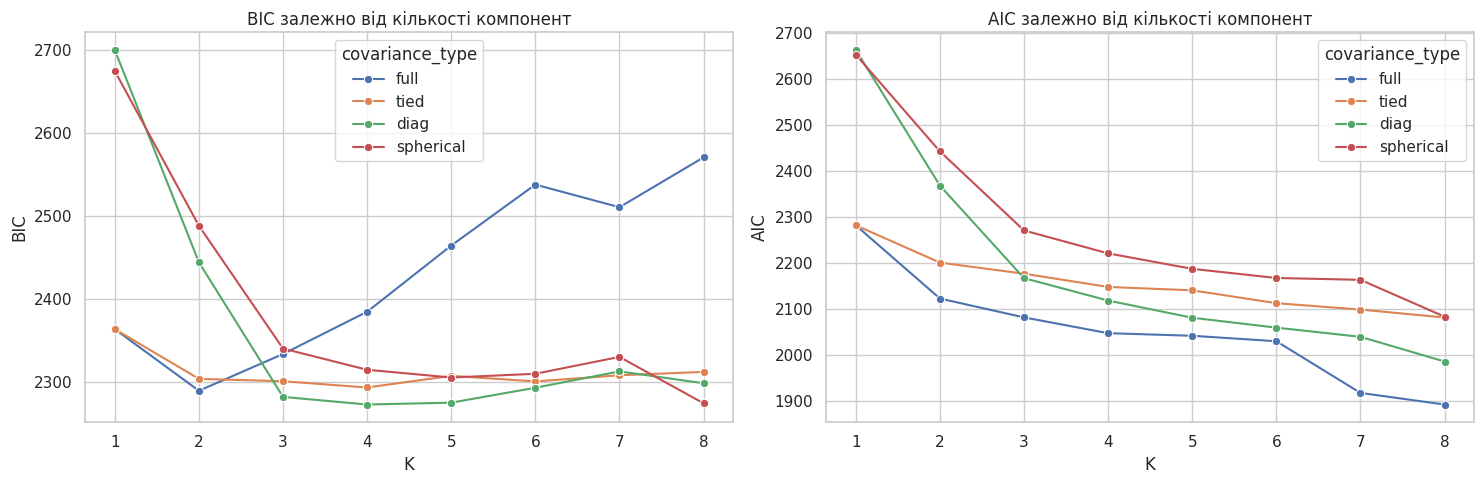

Найкраще K за BIC для кожного типу коваріації:
covariance_type  K    BIC    AIC
           diag  4 2273.4 2118.2
           full  2 2289.9 2122.6
      spherical  8 2274.8 2083.1
           tied  4 2293.9 2147.8


In [26]:
X = df_scaled.values
ks = range(1, 9)
rows = []
for cov in ['full', 'tied', 'diag', 'spherical']:
    for k in ks:
        gm = GaussianMixture(n_components=k, covariance_type=cov, n_init=10, random_state=RANDOM_STATE).fit(X)
        rows.append({'covariance_type': cov, 'K': k, 'BIC': gm.bic(X), 'AIC': gm.aic(X)})
ic = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, crit in zip(axes, ['BIC', 'AIC']):
    sns.lineplot(data=ic, x='K', y=crit, hue='covariance_type', marker='o', ax=ax)
    ax.set_title(f'{crit} залежно від кількості компонент')
plt.tight_layout()
plt.show()

print('Найкраще K за BIC для кожного типу коваріації:')
print(ic.loc[ic.groupby('covariance_type')['BIC'].idxmin()].round(1).to_string(index=False))

Критерій BIC (сильно штрафує складність при лише 155 спостереженнях) для повної коваріації мінімальний при $K=2$,
для `diag`/`tied` — при $K=4$; AIC для простіших типів коваріації допускає ще більше компонент. Тобто «природна» кількість
груп у даних невелика — 2–4. Оскільки ми хочемо порівняти кластери з трьома рівнями щастя
(низький / середній / високий), а $K=3$ лежить посередині цього діапазону, беремо
**`n_components = 3`, `covariance_type = 'full'`** (враховує сильні кореляції між економікою, здоров'ям та соцпідтримкою, див. крок 7).

**11.2. Навчання моделі.**

In [27]:
def doGMM(X, nclust=3, covariance_type='full', random_state=RANDOM_STATE):
    model = GaussianMixture(n_components=nclust, covariance_type=covariance_type,
                            init_params='kmeans', n_init=10, random_state=random_state)
    model.fit(X)
    return model, model.predict(X), model.predict_proba(X)

def order_clusters(labels, score):
    """Перенумеровує кластери за зростанням середнього Happiness.Score (0 — найменш щасливий)."""
    means = pd.Series(score).groupby(labels).mean().sort_values()
    mapping = {old: new for new, old in enumerate(means.index)}
    return np.vectorize(mapping.get)(labels)

gmm, labels, proba = doGMM(X, nclust=3)
df['GMM_Cluster'] = order_clusters(labels, df[target].values)
df['GMM_Proba_max'] = proba.max(axis=1)

print('Збіжність EM:', gmm.converged_, '| кількість ітерацій:', gmm.n_iter_)
print('Середня логправдоподібність:', round(gmm.score(X), 3))
print('Ваги компонент (pi_k):', gmm.weights_.round(3))
print('\nКількість країн у кластерах:')
print(df['GMM_Cluster'].value_counts().sort_index())

Збіжність EM: True | кількість ітерацій: 9
Середня логправдоподібність: -6.179
Ваги компонент (pi_k): [0.333 0.499 0.168]

Кількість країн у кластерах:
GMM_Cluster
0    50
1    79
2    26
Name: count, dtype: int64


,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Happiness.Score,n_countries
GMM_Cluster,,,,,,,,
0,0.560,0.925,0.273,0.343,0.256,0.114,4.206,50
1,1.074,1.273,0.650,0.397,0.204,0.075,5.579,79
2,1.529,1.439,0.786,0.571,0.359,0.287,6.877,26


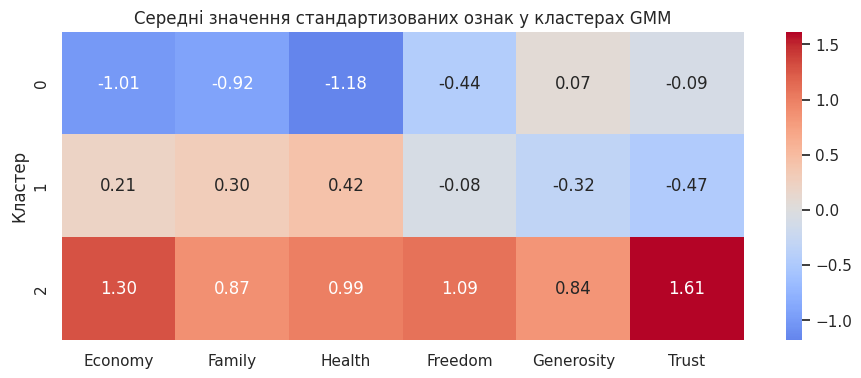

In [28]:
# Профіль кластерів в оригінальних одиницях
profile = df.groupby('GMM_Cluster')[features + [target]].mean()
profile['n_countries'] = df['GMM_Cluster'].value_counts().sort_index()
display(profile.round(3))

# Профіль кластерів у стандартизованих одиницях — наочно
plt.figure(figsize=(11, 4))
sns.heatmap(df_scaled.groupby(df['GMM_Cluster'].values).mean().rename(columns=short),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Середні значення стандартизованих ознак у кластерах GMM')
plt.ylabel('Кластер')
plt.show()

In [29]:
# Приклади країн у кожному кластері та впевненість моделі
for c in sorted(df['GMM_Cluster'].unique()):
    sub = df[df['GMM_Cluster'] == c].sort_values(target, ascending=False)
    print(f'Кластер {c} ({len(sub)} країн, середній Happiness.Score = {sub[target].mean():.2f}):')
    print('   ', ', '.join(sub['Country'].head(12)), '...')
print('\nЧастка країн, віднесених до кластера з ймовірністю > 0.9:',
      round((df['GMM_Proba_max'] > 0.9).mean(), 3))

Кластер 0 (50 країн, середній Happiness.Score = 4.21):
    Uzbekistan, Turkmenistan, Pakistan, Somalia, Nigeria, Bhutan, South Africa, Sierra Leone, Cameroon, Iran, Bangladesh, Namibia ...
Кластер 1 (79 країн, середній Happiness.Score = 5.58):
    Israel, Costa Rica, Chile, Brazil, Czech Republic, Argentina, Mexico, Uruguay, Guatemala, Panama, France, Thailand ...
Кластер 2 (26 країн, середній Happiness.Score = 6.88):
    Norway, Denmark, Iceland, Switzerland, Finland, Netherlands, Canada, New Zealand, Sweden, Australia, Austria, United States ...

Частка країн, віднесених до кластера з ймовірністю > 0.9: 0.916


Adjusted Rand Index (ARI): 0.363
Normalized Mutual Info (NMI): 0.421
Silhouette score: 0.273


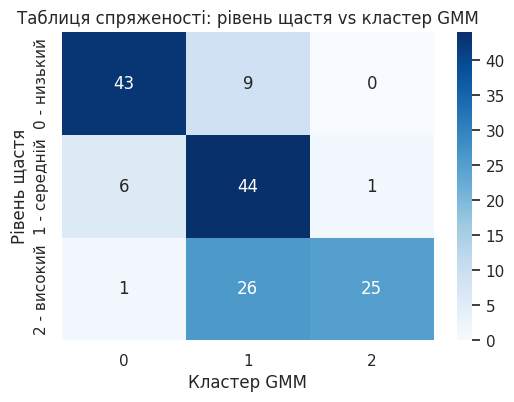

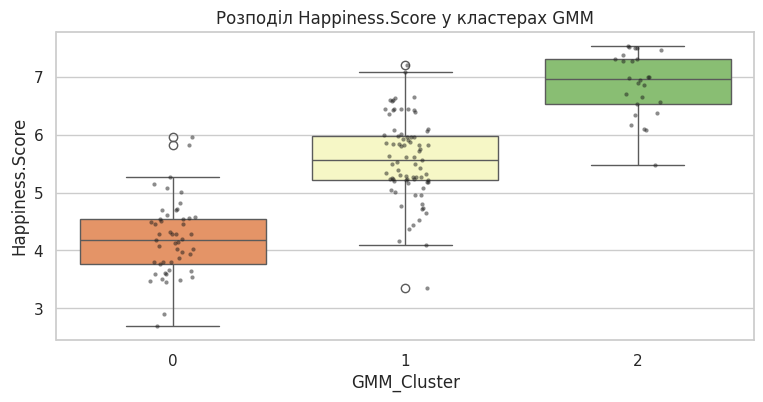

In [30]:
# Оцінка якості: порівняння з «еталонним» розбиттям за терцилями Happiness.Score
y_true = df['Happiness.Level.code'].values
y_pred = df['GMM_Cluster'].values
print('Adjusted Rand Index (ARI):', round(adjusted_rand_score(y_true, y_pred), 3))
print('Normalized Mutual Info (NMI):', round(normalized_mutual_info_score(y_true, y_pred), 3))
print('Silhouette score:', round(silhouette_score(X, y_pred), 3))

ct = pd.crosstab(df['Happiness.Level'], df['GMM_Cluster'], rownames=['Рівень щастя'], colnames=['Кластер GMM'])
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Таблиця спряженості: рівень щастя vs кластер GMM')
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='GMM_Cluster', y=target, palette='RdYlGn')
sns.stripplot(data=df, x='GMM_Cluster', y=target, color='k', size=3, alpha=0.5)
plt.title('Розподіл Happiness.Score у кластерах GMM')
plt.show()

**Висновки кроку 11:**
- EM-алгоритм збігся за 9 ітерацій; 92% країн віднесено до свого кластера з ймовірністю > 0.9 (кластери добре розділені).
- Після перенумерації за середнім `Happiness.Score` кластери чітко впорядковані:
  - **кластер 0** (50 країн, середній score ≈ 4.21) — бідні країни з низькими здоров'ям і соцпідтримкою:
    Африка на південь від Сахари, Південна Азія (Індія, Пакистан, Бангладеш, Афганістан), Іран, Ірак, Сирія, Ємен, Туркменістан, Узбекистан, Гаїті;
  - **кластер 1** (79 країн, ≈ 5.58) — велика «середня» група: Латинська Америка, Центральна, Східна та Південна Європа
    (включно з Францією, Італією, Іспанією), Росія, Україна, Китай, Японія, Південна Корея, Північна Африка;
  - **кластер 2** (26 країн, ≈ 6.88) — найбагатші країни з високими здоров'ям, свободою, щедрістю та довірою до уряду:
    Скандинавія, Західна Європа, США, Канада, Австралія, Нова Зеландія, Сінгапур, Гонконг, а також багаті країни Перської затоки.
- Середній `Happiness.Score` монотонно зростає від кластера 0 до кластера 2, хоча цільова ознака **не використовувалась** при навчанні.
- Збіг із терцилями щастя помірний (ARI ≈ 0.36, NMI ≈ 0.42): найбільше розбіжностей на межі «середній/високий» —
  GMM виділяє не рівні за розміром групи, а природні «згустки» у просторі факторів.

## Крок 12. Теплова мапа розподілу країн за кластерами

In [31]:
df['GMM_Cluster_str'] = df['GMM_Cluster'].astype(str)
fig = px.choropleth(df,
                    locations='Country',
                    locationmode='country names',
                    color='GMM_Cluster_str',
                    category_orders={'GMM_Cluster_str': ['0', '1', '2']},
                    color_discrete_sequence=['#d73027', '#fee08b', '#1a9850'],
                    hover_data=['Happiness.Score', 'Happiness.Rank', 'GMM_Proba_max'],
                    labels={'GMM_Cluster_str': 'Кластер GMM'})
fig.update_layout(title='Кластери країн (GMM, 6 факторів, StandardScaler, K=3)')
fig.show()

**Висновки кроку 12:** на мапі кластерів видно ту ж географічну структуру, що й на мапі індексу щастя (крок 8):
Африка на південь від Сахари та Південна Азія — кластер 0 (червоний); Північна Америка, Західна та Північна Європа,
Австралія й Нова Зеландія — кластер 2 (зелений); Латинська Америка, Східна та Південна Європа, більша частина Азії — кластер 1 (жовтий).
Основні розбіжності з мапою «еталонних» рівнів щастя:
- кластер 2 значно менший за терциль «високий» (26 проти 52 країн): частина щасливих країн (Коста-Ріка, Чилі, Бразилія, Мексика,
  Франція, Іспанія, Чехія) потрапила до «середнього» кластера — їхнє щастя вище, ніж можна передбачити з факторів;
- до кластера 2 потрапили країни Перської затоки (Саудівська Аравія, Кувейт, Бахрейн) — через високі ВВП і довіру до уряду;
- кластер 0 охоплює також Іран, Ірак, Центральну Азію, ПАР — через нижчу соцпідтримку та здоров'я, хоча їхній індекс щастя середній.

## Крок 13. Дослідження впливу різного набору ознак на результат кластеризації

Порівнюємо кілька наборів ознак, три способи масштабування та два типи коваріаційної матриці (усього 36 моделей, $K=3$).
Якість оцінюємо метриками:
- **ARI** та **NMI** — узгодженість кластерів із терцилями `Happiness.Score` (1 — повний збіг, 0 — випадкове розбиття);
- **Silhouette** — внутрішня компактність і відокремленість кластерів (без урахування цільової ознаки).

In [32]:
feature_sets = {
    'all_6 (усі 6 факторів)': features,
    'econ_3 (GDP, Family, Health)': ['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.'],
    'gdp_health (GDP, Health)': ['Economy..GDP.per.Capita.', 'Health..Life.Expectancy.'],
    'top_4 (GDP, Family, Health, Freedom)': ['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom'],
    'soc_3 (Freedom, Generosity, Trust)': ['Freedom', 'Generosity', 'Trust..Government.Corruption.'],
    'all_7 (6 факторів + Dystopia)': features + ['Dystopia.Residual'],
}

results = []
all_labels = {}
for fs_name, cols in feature_sets.items():
    for st in ['std', 'minmax', 'norm']:
        Xs = data_scale(df[cols], scaler_type=st)
        for cov in ['full', 'diag']:
            _, lab, _ = doGMM(Xs, nclust=3, covariance_type=cov)
            lab = order_clusters(lab, df[target].values)
            all_labels[(fs_name, st, cov)] = lab
            results.append({'feature_set': fs_name, 'scaler': st, 'covariance': cov,
                            'ARI': adjusted_rand_score(y_true, lab),
                            'NMI': normalized_mutual_info_score(y_true, lab),
                            'Silhouette': silhouette_score(Xs, lab),
                            'sizes': sorted(np.bincount(lab).tolist())})
res = pd.DataFrame(results).sort_values('ARI', ascending=False).reset_index(drop=True)
res.round(3)

,feature_set,scaler,covariance,ARI,NMI,Silhouette,sizes
0,"econ_3 (GDP, Family, Health)",minmax,full,0.452,0.430,0.382,"[48, 53, 54]"
1,"econ_3 (GDP, Family, Health)",std,full,0.440,0.416,0.351,"[46, 50, 59]"
2,all_7 (6 факторів + Dystopia),std,full,0.408,0.451,0.237,"[27, 60, 68]"
3,"econ_3 (GDP, Family, Health)",minmax,diag,0.401,0.407,0.398,"[47, 49, 59]"
4,"econ_3 (GDP, Family, Health)",std,diag,0.393,0.400,0.369,"[47, 50, 58]"
5,"top_4 (GDP, Family, Health, Freedom)",std,diag,0.365,0.422,0.294,"[36, 45, 74]"
6,"top_4 (GDP, Family, Health, Freedom)",minmax,diag,0.365,0.422,0.312,"[36, 45, 74]"
7,all_6 (усі 6 факторів),std,full,0.363,0.421,0.273,"[26, 50, 79]"
8,all_6 (усі 6 факторів),minmax,diag,0.330,0.385,0.316,"[29, 49, 77]"
9,all_6 (усі 6 факторів),std,diag,0.321,0.377,0.289,"[29, 50, 76]"


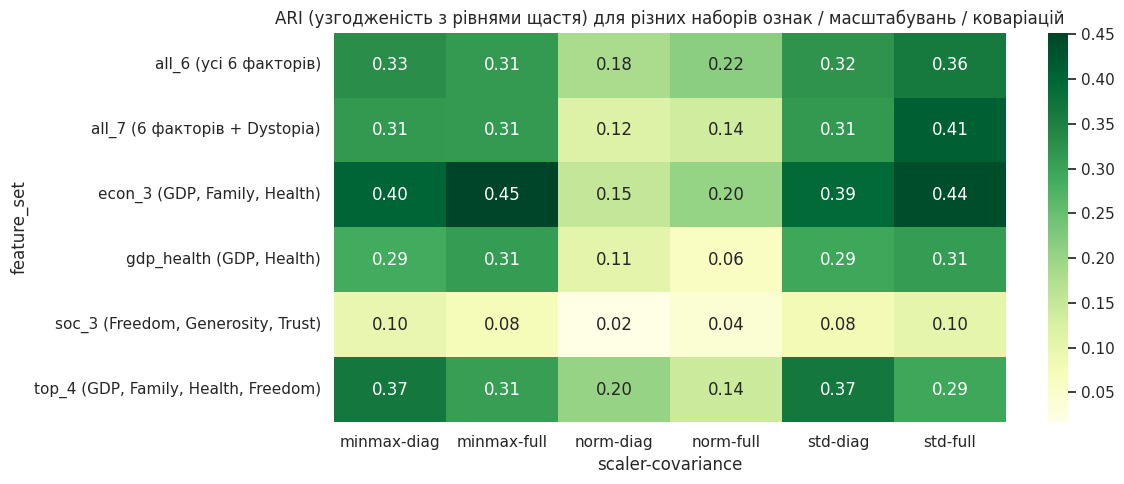

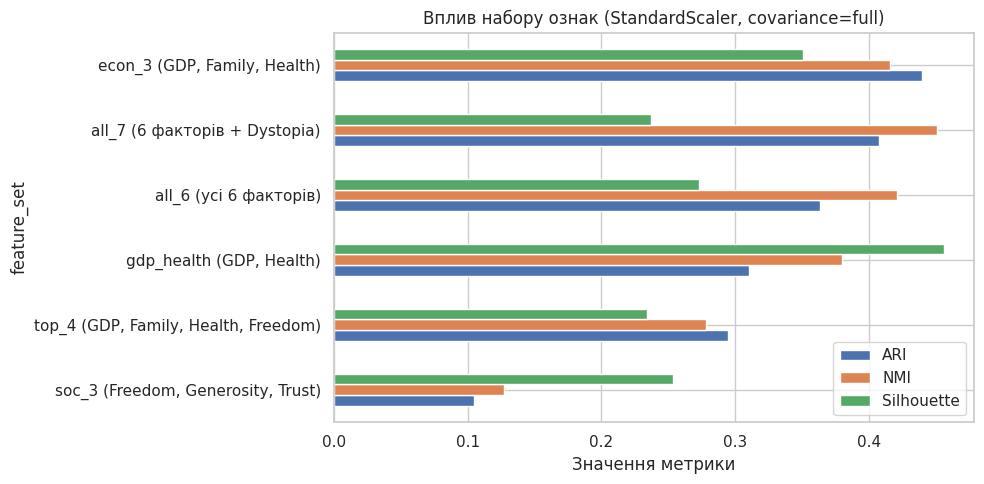

In [33]:
pivot = res.pivot_table(index='feature_set', columns=['scaler', 'covariance'], values='ARI')
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGn')
plt.title('ARI (узгодженість з рівнями щастя) для різних наборів ознак / масштабувань / коваріацій')
plt.tight_layout()
plt.show()

res_std_full = res[(res.scaler == 'std') & (res.covariance == 'full')].set_index('feature_set')
res_std_full[['ARI', 'NMI', 'Silhouette']].sort_values('ARI').plot.barh(figsize=(10, 5))
plt.title('Вплив набору ознак (StandardScaler, covariance=full)')
plt.xlabel('Значення метрики')
plt.tight_layout()
plt.show()

In [34]:
# Мапи для найкращого та найгіршого набору ознак (StandardScaler, full)
for fs_name in ['econ_3 (GDP, Family, Health)', 'soc_3 (Freedom, Generosity, Trust)']:
    lab = all_labels[(fs_name, 'std', 'full')]
    tmp = df[['Country', target]].assign(Cluster=lab.astype(str))
    ari = adjusted_rand_score(y_true, lab)
    fig = px.choropleth(tmp, locations='Country', locationmode='country names', color='Cluster',
                        category_orders={'Cluster': ['0', '1', '2']},
                        color_discrete_sequence=['#d73027', '#fee08b', '#1a9850'],
                        hover_data=[target])
    fig.update_layout(title=f'GMM, ознаки: {fs_name}; ARI = {ari:.2f}')
    fig.show()
    print(tmp.groupby('Cluster')[target].agg(['count', 'mean']).round(2))

         count  mean
Cluster             
0           50  4.18
1           46  5.30
2           59  6.39


         count  mean
Cluster             
0           70  4.77
1           55  5.48
2           30  6.48


**Висновки кроку 13:**
- **Набір ознак має найбільший вплив** на результат. Найкраще узгодження з рівнями щастя дає набір
  **`econ_3` (економіка, соцпідтримка, здоров'я)**: ARI ≈ 0.44–0.45, NMI ≈ 0.42–0.43, при цьому кластери
  майже рівні за розміром. Це саме ті ознаки, що найсильніше корелюють із `Happiness.Score` (крок 7).
- Додавання `Freedom`, `Generosity`, `Trust` (набори `all_6`, `top_4`) якість відносно рівнів щастя **не покращує**,
  а часто погіршує: ці ознаки слабко пов'язані з індексом щастя та мають асиметричні розподіли з «викидами»
  (напр., кілька країн з дуже високою довірою), тож GMM витрачає компоненти на опис цих особливостей.
- Набір **`soc_3` (свобода, щедрість, довіра)** майже не відтворює рівні щастя (ARI ≈ 0.08–0.11) — кластери за «ціннісними» ознаками
  описують зовсім інший поділ країн (наприклад, за рівнем корупції та благодійності), а не добробут.
- Набір **`gdp_health`** дає найкомпактніші кластери (найвищий Silhouette ≈ 0.46–0.49), але ARI нижчий, ніж у `econ_3` —
  без соцпідтримки гірше розрізняються країни середнього рівня.
- Додавання `Dystopia.Residual` (`all_7`) при `StandardScaler`+`full` трохи підвищує ARI (≈ 0.41), бо цей залишок входить до `Happiness.Score`,
  але це вже частковий «витік» цільової ознаки.
- **Масштабування:** `StandardScaler` і `MinMaxScaler` дають близькі результати (лінійні перетворення), а **`Normalizer`
  суттєво погіршує** узгодженість (ARI ≲ 0.2, часто вироджені кластери з 1–6 країн), бо знищує інформацію про загальний рівень добробуту.
- **Тип коваріації:** `full` зазвичай кращий для корельованих ознак (econ_3, all_6), `diag` — інколи для змішаних наборів;
  різниця менша, ніж від вибору ознак.

## Крок 14. Загальний висновок

1. **Дані.** Звіт World Happiness Report 2017 містить 155 країн без пропусків. Індекс щастя `Happiness.Score` розподілений
   майже нормально, тоді як більшість факторів мають асиметричні розподіли (економіка, здоров'я, соцпідтримка — зліва;
   довіра до уряду й щедрість — справа).
2. **Зв'язки.** Індекс щастя найсильніше лінійно пов'язаний з економікою (r ≈ 0.81), здоров'ям (≈ 0.78) та соцпідтримкою (≈ 0.75);
   ці три фактори сильно корелюють і між собою. Свобода та довіра мають помірний зв'язок, щедрість — практично ніякого.
3. **Підготовка.** Ознаки мають різні масштаби, тому масштабування обов'язкове. `StandardScaler`/`MinMaxScaler` зберігають
   структуру даних і підходять для GMM; `Normalizer` (нормування рядків) для цієї задачі непридатний.
4. **Кластеризація GMM** (EM-алгоритм, $K=3$, повна коваріація) без використання цільової ознаки виділила три групи країн,
   які **впорядковуються за рівнем щастя** (середній score 4.21 → 5.58 → 6.88): «бідні/нещасливі» (Африка, Південна Азія), «середні»
   (Латинська Америка, Східна й Південна Європа, більша частина Азії) і «багаті/щасливі» (Західна та Північна Європа, Північна Америка,
   Австралія, Нова Зеландія, Сінгапур, країни Перської затоки).
   Мапа кластерів візуально добре повторює мапу індексу щастя.
5. **Відповідність оригінальному розподілу** — **помірна**: ARI ≈ 0.36–0.45, NMI ≈ 0.42–0.45 (для найкращих конфігурацій).
   Повного збігу і не слід очікувати, адже:
   - терцилі — штучний поділ на рівні групи, а GMM шукає природні «згустки» різного розміру;
   - частина індексу щастя (`Dystopia.Residual`) не пояснюється факторами;
   - є країни, де щастя «випадає» з економічного профілю (Латинська Америка — щасливіші, ніж дозволяє економіка;
     деякі багаті країни Азії та Перської затоки — навпаки).
6. **Найкращий результат** дає кластеризація за трьома «матеріально-соціальними» факторами
   (**GDP, Family, Health**) зі стандартизацією — вони найбільш інформативні щодо рівня щастя.
   Ознаки свободи, щедрості та довіри формують інший, «інституційно-ціннісний» поділ країн.
7. **Переваги GMM** у цій задачі: м'яка (ймовірнісна) кластеризація (для кожної країни відома ймовірність належності до кластера),
   еліпсоїдальні кластери з урахуванням кореляції ознак (`full` covariance) та можливість обирати кількість кластерів за BIC/AIC.